Download dei dati storici per AAPL in corso...


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532719,24.064282,23.346673,23.984547,257142000
2015-01-06,23.534935,23.794071,23.173914,23.596950,263188400
2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


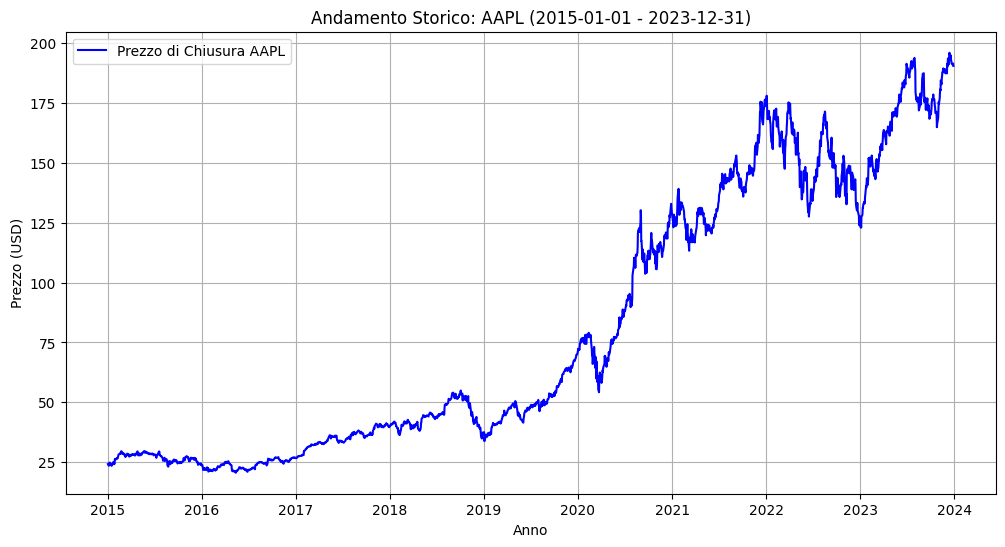


Totale giorni di borsa a disposizione: 2264


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


TICKER = 'AAPL' 
DATA_INIZIO = '2015-01-01'
DATA_FINE = '2023-12-31'
print(f"Download dei dati storici per {TICKER} in corso...")

df = yf.download(TICKER, start=DATA_INIZIO, end=DATA_FINE)
display(df.head())

#Il prezzo di chiusura
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(df.index, df['Close'], label=f'Prezzo di Chiusura {TICKER}', color='blue')
plt.title(f'Andamento Storico: {TICKER} ({DATA_INIZIO} - {DATA_FINE})')
plt.xlabel('Anno')
plt.ylabel('Prezzo (USD)')
plt.legend()
plt.grid(True)
plt.show()

print(f"\nTotale giorni di borsa a disposizione: {len(df)}")

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

dataset = df['Close'].values
dataset = dataset.reshape(-1, 1)

# NORMALIZZAZIONE 0-1
print("Normalizzazione dei dati in corso...")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

print(f"Prezzo originale (es.): {dataset[0][0]:.2f}$ -> Prezzo scalato: {scaled_data[0][0]:.4f}")


# 80% iniziale per il train, 20% cronologico per il test.
training_data_len = int(np.ceil(len(dataset) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# Sliding Window (60 giorni)
window_size = 60

X_train = []
y_train = []

print(f"Creazione delle sequenze (finestra di {window_size} giorni)...")
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# 5. RESHAPE PER LA LSTM
# Le LSTM di Keras richiedono input tridimensionali: [Numero di campioni, Finestra temporale, Numero di Features]
# Nel nostro caso: [X, 60 giorni, 1 feature (solo il prezzo Close)]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("\n--- RISULTATO DELLA PREPARAZIONE ---")
print(f"Forma di X_train (Input): {X_train.shape}")
print(f"Forma di y_train (Target): {y_train.shape}")